# ECG Heartbeat Classification Project
## Phase 3 — EDA and Feature Extraction

This notebook performs exploratory data analysis on the segmented
heartbeat dataset and extracts meaningful features from each beat
for use in machine learning classification in Phase 4.

### Import libraries and load saved dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import Counter

# Load the saved dataset from Phase 2
data_path = '../data'

X = np.load(os.path.join(data_path, 'X_beats.npy'))
y = np.load(os.path.join(data_path, 'y_labels.npy'))
y_binary = np.load(os.path.join(data_path, 'y_binary.npy'))

print("Dataset loaded successfully!")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y_binary shape: {y_binary.shape}")
print(f"\nClass distribution:")
for label, count in Counter(y).most_common():
    print(f"  {label}: {count} ({count/len(y)*100:.1f}%)")

Dataset loaded successfully!
X shape: (102382, 360)
y shape: (102382,)
y_binary shape: (102382,)

Class distribution:
  N: 75011 (73.3%)
  L: 8071 (7.9%)
  R: 7255 (7.1%)
  V: 7129 (7.0%)
  A: 2546 (2.5%)
  f: 982 (1.0%)
  F: 802 (0.8%)
  j: 229 (0.2%)
  a: 150 (0.1%)
  E: 106 (0.1%)
  J: 83 (0.1%)
  e: 16 (0.0%)
  S: 2 (0.0%)


### Visualise average beat shape per class

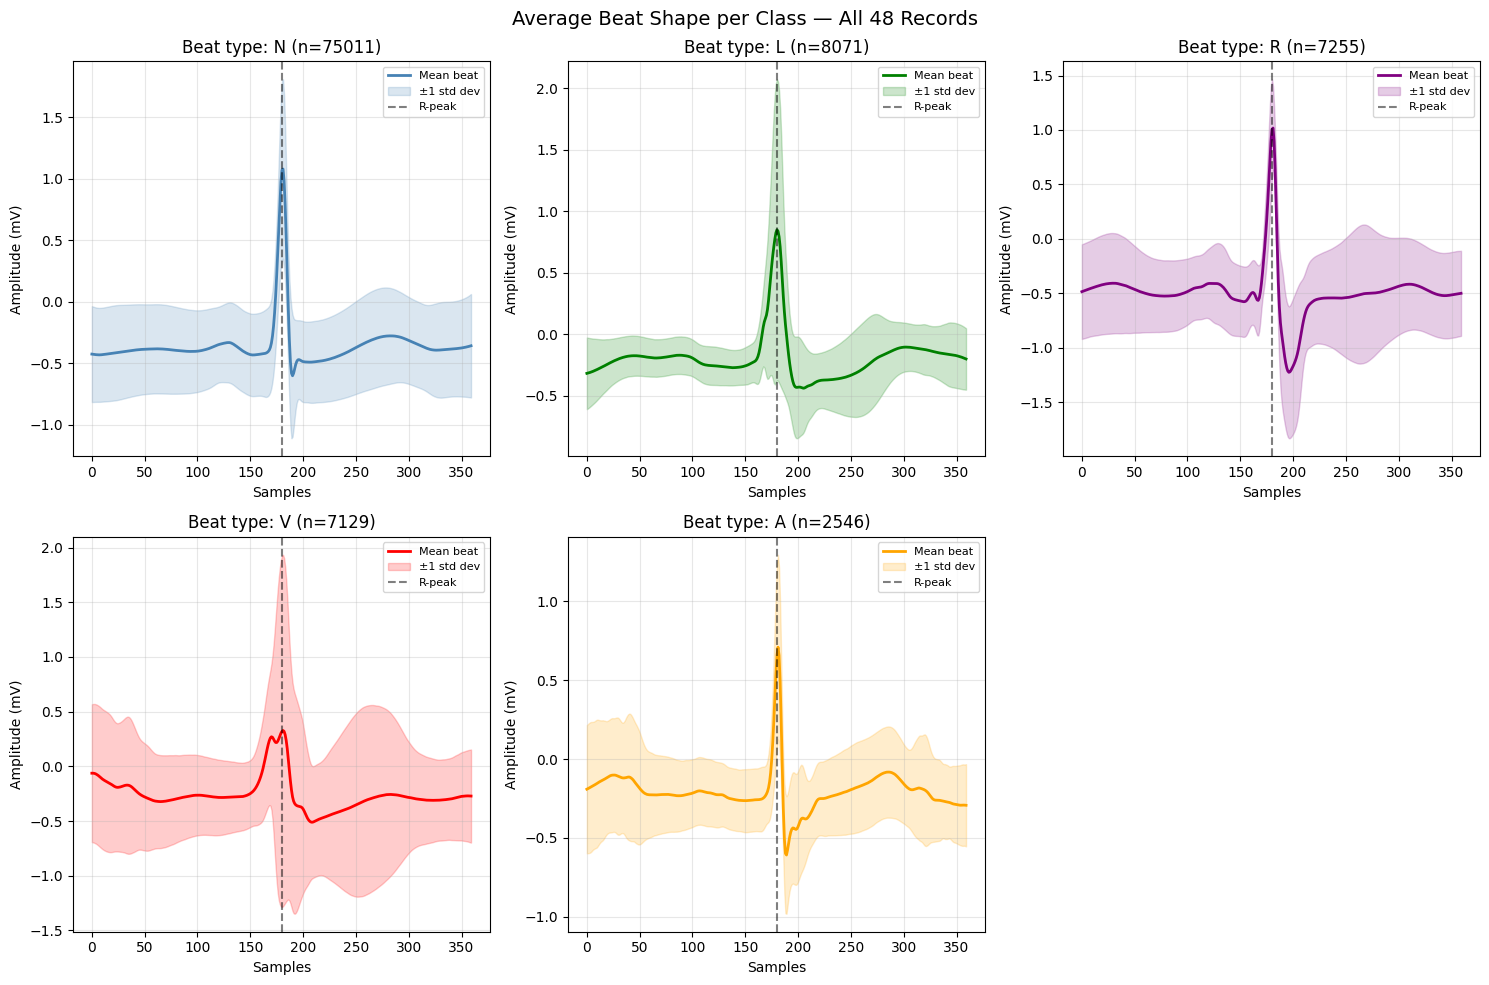

In [3]:
# Get the main beat types we care about
main_types = ['N', 'L', 'R', 'V', 'A']
colors = ['steelblue', 'green', 'purple', 'red', 'orange']

plt.figure(figsize=(15, 10))

for i, (beat_type, color) in enumerate(zip(main_types, colors)):
    # Get all beats of this type
    indices = np.where(y == beat_type)[0]
    beats_of_type = X[indices]
    
    # Calculate average beat shape
    mean_beat = np.mean(beats_of_type, axis=0)
    std_beat = np.std(beats_of_type, axis=0)
    
    plt.subplot(2, 3, i+1)
    plt.plot(mean_beat, color=color, linewidth=2, label=f'Mean beat')
    plt.fill_between(range(360), 
                     mean_beat - std_beat, 
                     mean_beat + std_beat, 
                     alpha=0.2, color=color, label='±1 std dev')
    plt.axvline(x=180, color='black', linestyle='--', alpha=0.5, label='R-peak')
    plt.title(f'Beat type: {beat_type} (n={len(indices)})')
    plt.xlabel('Samples')
    plt.ylabel('Amplitude (mV)')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)

plt.suptitle('Average Beat Shape per Class — All 48 Records', fontsize=14)
plt.tight_layout()
plt.show()

### Observations from average beat shapes

The average beat shape plots reveal clear visual differences between
beat types across all 48 records:

- **Normal (N):** Sharp consistent R-peak at sample 180 with narrow
  standard deviation band, indicating high consistency across patients.

- **Left Bundle Branch Block (L):** Similar peak position to Normal
  but with distinctly different morphology around the QRS complex,
  reflecting the abnormal electrical conduction pathway.

- **Right Bundle Branch Block (R):** Notably inverted peak compared
  to Normal — the R-peak goes negative — due to reversed electrical
  signal direction through the right ventricle.

- **PVC (V):** Very wide standard deviation band indicating high
  variability across patients. The mean shape is almost flat,
  showing how differently PVC beats manifest between individuals.

- **Atrial Premature (A):** Visually most similar to Normal, confirming
  that A beats will be the most challenging class for the ML model
  to distinguish correctly in Phase 4.